# 8. 複数の目的変数を予測し、複数のサンプルを Bayesian Optimization により抽出する（EI / UCB 獲得関数）

- 複数の目的変数を GPR で予測し、獲得関数でスコア化した候補を **設定した回数だけ** 連続選抜する

---

## ユーザー設定（ここを編集してください）
**以下のセルで目的変数などを指定してください。1.Preparation.ipynb と同じ設定を使用します。**

- **`constrained_ei`**: $\text{Score} = \mathrm{EI}_{\text{PLQY}}(x) \times P(600 \le \lambda_{\mathrm{PL}}(x) \le 900)$
- **`weighted_ucb`**: 各目的の UCB を候補集合内で標準化したうえで $w_{\text{PLQY}} \, \mathrm{UCB}_{\text{PLQY}}^{\mathrm{z}} + w_{\text{emission}} \, \mathrm{UCB}_{\text{emission}}^{\mathrm{z}}$

- モードは下の `acquisition_mode` で切り替え、選抜時の値は `bo_selected_summary` に記録され、最後に表・構造式で確認できる

## ライブラリ読み込み

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import norm
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_predict
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import WhiteKernel, RBF, ConstantKernel, Matern, DotProduct
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from IPython.display import display
from rdkit import Chem
from rdkit.Chem import Draw

np.random.seed(1234)

## 学習データとテストデータ読み込み
`6.BO_multi-sample.ipynb` と同じデータソースを使い、目的変数2つ（発光波長・PLQY）と記述子を準備

In [ ]:
# ============================================================
# ユーザー設定: 1.Preparation.ipynb と同じ設定を使用
# ============================================================

# 目的変数の列名（リストで複数指定可能）
TARGET_COLS = ["Emission max (nm)", "Quantum yield"]

# 使用する記述子のタイプ
DESCRIPTOR_TYPE = "rdkit"  # "rdkit" or "mordred_2d" or "mordred_3d" or "fp"

# SMILES列の名前
SMILES_COL = "Chromophore"

# PTR（Probability of Target Range）の範囲設定
# 目的変数ごとに [min, max] を指定
PTR_RANGES = {
    "Emission max (nm)": [600, 900],
    "Quantum yield": [0.5, 1.0],
}

# ============================================================
print(f"目的変数: {TARGET_COLS}")
print(f"記述子タイプ: {DESCRIPTOR_TYPE}")
print(f"PTR範囲: {PTR_RANGES}")

In [2]:
# データ読み込み（設定変数を使用）
dataset_train = pd.read_csv("../data/dataset_train.csv", index_col=0)
target = dataset_train[TARGET_COLS]

if DESCRIPTOR_TYPE == "rdkit":
    des_train = pd.read_csv("outputs/descriptors/rdkit/X_train_rdkit_processed.csv", index_col=0)
    des_test = pd.read_csv("outputs/descriptors/rdkit/X_test_rdkit_processed.csv", index_col=0)
elif DESCRIPTOR_TYPE == "mordred_2d":
    des_train = pd.read_csv("outputs/descriptors/mordred_2d/X_train_mordred_2d_processed.csv", index_col=0)
    des_test = pd.read_csv("outputs/descriptors/mordred_2d/X_test_mordred_2d_processed.csv", index_col=0)
elif DESCRIPTOR_TYPE == "mordred_3d":
    des_train = pd.read_csv("outputs/descriptors/mordred_3d/X_train_mordred_3d_processed.csv", index_col=0)
    des_test = pd.read_csv("outputs/descriptors/mordred_3d/X_test_mordred_3d_processed.csv", index_col=0)
elif DESCRIPTOR_TYPE == "fp":
    des_train = pd.read_csv("outputs/descriptors/fp/X_train_fp.csv", index_col=0)
    des_test = pd.read_csv("outputs/descriptors/fp/X_test_fp.csv", index_col=0)
else:
    raise ValueError(f"未知の DESCRIPTOR_TYPE: {DESCRIPTOR_TYPE}")

# 目的変数と記述子を結合
dataset = target.join(des_train, how="inner")

# テストデータ
x_prediction = des_test.copy()

print(f"dataset: {dataset.shape}")
print(f"x_prediction: {x_prediction.shape}")

dataset: (13132, 208)
x_prediction: (7104, 206)


In [3]:
#（任意）学習データを間引いて試行時間を短縮するテンプレート。既定はコメントアウト。必要ならコメント解除してから実行。

# 学習データを間引く
MAX_TRAIN_SAMPLES = 2000
RANDOM_STATE = 1234

if len(dataset) > MAX_TRAIN_SAMPLES:
    dataset = dataset.sample(n=MAX_TRAIN_SAMPLES, random_state=RANDOM_STATE)
    print(f"dataset を {MAX_TRAIN_SAMPLES} 件に間引きました: {dataset.shape}")
else:
    print(f"dataset 件数が {MAX_TRAIN_SAMPLES} 以下のため間引きなし: {dataset.shape}")

dataset を 2000 件に間引きました: (2000, 208)


## BO設定

- `sample_program_05_04_bayesian_optimization_multi_y_multi_sample.py` に合わせて、複数目的・複数サンプル選択の設定を行う

In [4]:
# 候補数
number_of_selecting_samples = 20

# 回帰手法
regression_method = "gpr_one_kernel"  # "gpr_one_kernel" or "gpr_kernels"

# カーネル番号、gpr_one_kernel のときに使用
kernel_number = 7

# CV の分割: "kfold" または "loo"（enable_cv_metrics および regression_method=="gpr_kernels" で使用）
cv_strategy = "kfold"  # "kfold" or "loo"

# kfold のときの分割数（loo のときは未使用）
fold_number = 5

# True: CV指標を計算 / False: CV指標計算をスキップして高速化
enable_cv_metrics = True

# 「学習データの極値から、標準偏差の何割ぶん緩めるか」という係数で、0.01 なら 標準偏差の 1% ぶんだけ閾値をずらすイメージ
relaxation = 0.01

# 獲得関数: "constrained_ei"（EI_PLQY × PTR 波長）または "weighted_ucb"（UCB を候補集合内で標準化して加重和）
acquisition_mode = "constrained_ei"  # "constrained_ei" or "weighted_ucb"

# UCB の κ（weighted_ucb のみ）
kappa_ucb = 2.0

# weighted_ucb の重み（単位が nm と QY で異なるため、候補集合内 z 化した UCB に対する重み）
w_ucb_plqy = 0.5
w_ucb_emission = 0.5

### 目的変数と制約

- ノート7の `settings`（PI/PTR 表）の代わりに、2目的の列名と **constrained_ei 用の発光波長範囲** を定義
- PLQY は獲得で **EI** を使うため、ここでは範囲を書かない


In [5]:
# 目的変数（データ読み込みセルの target と列順を一致させる）
y_columns = ["Emission max (nm)", "Quantum yield"]
number_of_y_variables = len(y_columns)

# constrained_ei 用: 発光波長がターゲット範囲に入る確率 P(λ_low ≤ λ ≤ λ_high) [nm]
emission_lower_nm = 600
emission_upper_nm = 900
if emission_lower_nm >= emission_upper_nm:
    raise ValueError("emission_lower_nm は emission_upper_nm より小さくしてください。")

display(
    pd.Series(
        {
            "number_of_y_variables": number_of_y_variables,
            "y_columns": ", ".join(y_columns),
            "emission_lower_nm": emission_lower_nm,
            "emission_upper_nm": emission_upper_nm,
        },
        name="bo_target_config",
    )
)

number_of_y_variables                                   2
y_columns                Emission max (nm), Quantum yield
emission_lower_nm                                     600
emission_upper_nm                                     900
Name: bo_target_config, dtype: object

In [6]:
# 目的変数の個数・列名
if number_of_y_variables != (dataset.shape[1] - x_prediction.shape[1]):
    raise Exception(
        "training dataset と x_prediction の目的変数・説明変数の数を確認してください。"
    )

if list(dataset.columns[:number_of_y_variables]) != y_columns:
    raise Exception(f"dataset の先頭 {number_of_y_variables} 列は {y_columns} である必要があります。")

# データ分割
y = dataset.iloc[:, :number_of_y_variables]
x = dataset.iloc[:, number_of_y_variables:]

# 標準偏差が 0 の特徴量を除去
deleting_variables = x.columns[x.std() == 0]
x = x.drop(deleting_variables, axis=1)
x_prediction = x_prediction.drop(deleting_variables, axis=1)

print("y:", y.shape)
print("x:", x.shape)
print("x_prediction:", x_prediction.shape)

y: (2000, 2)
x: (2000, 200)
x_prediction: (7104, 200)


In [7]:
# GPR で比較するカーネル候補を一覧定義する（単一カーネル番号指定や探索モードで利用）

kernels = [
    ConstantKernel() * DotProduct() + WhiteKernel(),
    ConstantKernel() * RBF() + WhiteKernel(),
    ConstantKernel() * RBF() + WhiteKernel() + ConstantKernel() * DotProduct(),
    ConstantKernel() * RBF(np.ones(x.shape[1])) + WhiteKernel(),
    ConstantKernel() * RBF(np.ones(x.shape[1])) + WhiteKernel() + ConstantKernel() * DotProduct(),
    ConstantKernel() * Matern(nu=1.5) + WhiteKernel(),
    ConstantKernel() * Matern(nu=1.5) + WhiteKernel() + ConstantKernel() * DotProduct(),
    ConstantKernel() * Matern(nu=0.5) + WhiteKernel(),
    ConstantKernel() * Matern(nu=0.5) + WhiteKernel() + ConstantKernel() * DotProduct(),
    ConstantKernel() * Matern(nu=2.5) + WhiteKernel(),
    ConstantKernel() * Matern(nu=2.5) + WhiteKernel() + ConstantKernel() * DotProduct(),
]

## 複数目的・複数サンプル BO 実行

各目的変数ごとに GPR を学習し、`acquisition_mode` に応じて獲得スコアを計算

- **constrained_ei**: 発光は `emission_lower_nm`–`emission_upper_nm` で **PTR**、PLQY は学習データ最大＋`relaxation` を基準とする **EI（最大化）** を計算し、**積**でスコア化する
- **weighted_ucb**: 各目的の **UCB（μ + κσ）** を候補集合内で **z スコア化**してから `w_ucb_*` で **加重和**する


In [8]:
# Utility

# 保存先（ノート7の出力と混ざらないよう別フォルダ）
save_dir = "outputs/result/bo_multi_y_acq_ei_ucb"
os.makedirs(save_dir, exist_ok=True)

def calc_rmse(y_true, y_pred):
    """
    sklearn のバージョン差異を避けるため RMSE を手計算する。
    """
    return np.sqrt(mean_squared_error(y_true, y_pred))


def _make_cv_splitter():
    """cv_strategy に応じて cross_val_predict 用の分割器を返す。"""
    if cv_strategy == "loo":
        return LeaveOneOut()
    if cv_strategy == "kfold":
        return KFold(n_splits=fold_number, random_state=9, shuffle=True)
    raise ValueError('cv_strategy は "kfold" または "loo" を指定してください。')


def select_model_for_target(autoscaled_x, autoscaled_y_col, y_col, mean_y, std_y):
    """
    目的変数1本分のGPRモデルを作る。
    """
    if regression_method == "gpr_one_kernel":
        return GaussianProcessRegressor(alpha=0, kernel=kernels[kernel_number])

    if regression_method == "gpr_kernels":
        cross_validation = _make_cv_splitter()
        r2cvs = []
        for kernel in kernels:
            model_tmp = GaussianProcessRegressor(alpha=0, kernel=kernel)
            estimated_y_in_cv = np.ndarray.flatten(
                cross_val_predict(model_tmp, autoscaled_x, autoscaled_y_col, cv=cross_validation)
            )
            estimated_y_in_cv = estimated_y_in_cv * std_y + mean_y
            r2cvs.append(r2_score(y_col, estimated_y_in_cv))
        optimal_kernel_number = np.where(r2cvs == np.max(r2cvs))[0][0]
        return GaussianProcessRegressor(alpha=0, kernel=kernels[optimal_kernel_number])

    raise ValueError(f"未知の回帰手法です: {regression_method}")

def calc_ptr_in_range(y_pred, y_std, lower, upper):
    """
    予測分布が [lower, upper] に入る確率（PTR）。
    constrained_ei の発光波長制約 P(λ_low ≤ λ ≤ λ_high) に用いる。
    """
    prob = norm.cdf(upper, loc=y_pred, scale=y_std) - norm.cdf(lower, loc=y_pred, scale=y_std)
    prob[y_std <= 0] = 0
    return prob


def calc_ei_maximize(y_col, y_pred, y_std, relaxation):
    """
    最大化目的の期待改善量 EI。現行ノートの PI と同じ incumbent 基準
    f* = max(y_train) + relaxation * std(y_train) を用いる。
    """
    f_star = y_col.max() + y_col.std() * relaxation
    sigma = np.maximum(y_std, 1e-12)
    delta = y_pred - f_star
    z = delta / sigma
    ei = delta * norm.cdf(z) + sigma * norm.pdf(z)
    ei = np.clip(ei, 0.0, None)
    ei[y_std <= 0] = np.maximum(0.0, y_pred[y_std <= 0] - f_star)
    return ei


def calc_ucb(y_pred, y_std, kappa):
    """UCB = μ + κ σ（最大化方向の上側信頼限界イメージ）。"""
    return y_pred + kappa * y_std

In [9]:
# =============================================================================
# - 毎ラウンド: GPR で各目的を予測 → acquisition_mode でスコア化 → 1 件選抜 → 擬似追加学習
# =============================================================================

# --- 初期化: 選抜結果の入れ物 ---
# next_samples: 選ばれた候補の記述子のみ（実験候補リスト）
# selected_summary_records: 各ラウンドの予測・獲得成分・スコア（後で bo_selected_summary に集約）
next_samples = pd.DataFrame([], columns=x_prediction.columns)
selected_summary_records = []

# --- 列名の定義（y の列順: 0=発光, 1=PLQY）---
_short_targets = ["emission", "plqy"]
if number_of_y_variables != len(_short_targets):
    raise ValueError("目的が2つ以外のときは _short_targets と列名の対応を編集してください。")

std_columns = [f"std_of_{name}" for name in _short_targets]

# 獲得関数の「成分」列名（モードで PTR×EI か UCB×UCB かが変わる）
if acquisition_mode == "constrained_ei":
    component_columns = ["PTR_emission", "EI_plqy"]
elif acquisition_mode == "weighted_ucb":
    component_columns = ["UCB_emission", "UCB_plqy"]
else:
    raise ValueError('acquisition_mode は "constrained_ei" または "weighted_ucb" を指定してください。')

# --- CSV ファイル名の接尾辞 ---
# GPR の予測平均・標準偏差は獲得関数に依存しない（同じモデル・同じ候補なら同じ値）
_csv_gpr = regression_method
# 獲得成分・スコア・選抜結果はモードで数値が変わるため acquisition_mode を付与
_csv_acq = f"{regression_method}_{acquisition_mode}"

# ラウンドごとの BO（number_of_selecting_samples 回）学習
for sample_number in range(number_of_selecting_samples):

    # 毎ラウンド、学習データ基準でオートスケール
    autoscaled_y = (y - y.mean()) / y.std()
    autoscaled_x = (x - x.mean()) / x.std()
    autoscaled_x_prediction = (x_prediction - x.mean()) / x.std()

    mean_of_y = y.mean()
    std_of_y = y.std()

    # 2目的分の予測値・不確かさ・確率を格納
    estimated_y_prediction_all = np.zeros((x_prediction.shape[0], number_of_y_variables))
    std_of_estimated_y_prediction_all = np.zeros((x_prediction.shape[0], number_of_y_variables))
    acquisition_components = np.zeros((x_prediction.shape[0], number_of_y_variables))

    # 目的変数ごとに GPR を学習し、候補への予測と獲得「成分」を計算
    for y_number in range(number_of_y_variables):
        y_col = y.iloc[:, y_number]
        model = select_model_for_target(
            autoscaled_x,
            autoscaled_y.iloc[:, y_number],
            y_col,
            mean_of_y.iloc[y_number],
            std_of_y.iloc[y_number],
        )
        model.fit(autoscaled_x, autoscaled_y.iloc[:, y_number])

        # 1ラウンド目のみ学習性能を確認
        if sample_number == 0:
            autoscaled_estimated_y, _ = model.predict(autoscaled_x, return_std=True)
            estimated_y = autoscaled_estimated_y * y_col.std() + y_col.mean()
            print(f"[{y.columns[y_number]}] r^2 for training data:", r2_score(y_col, estimated_y))
            print(f"[{y.columns[y_number]}] RMSE for training data:", calc_rmse(y_col, estimated_y))
            print(f"[{y.columns[y_number]}] MAE for training data:", mean_absolute_error(y_col, estimated_y))

            if enable_cv_metrics:
                cross_validation = _make_cv_splitter()
                autoscaled_estimated_y_in_cv = cross_val_predict(
                    model, autoscaled_x, autoscaled_y.iloc[:, y_number], cv=cross_validation
                )
                estimated_y_in_cv = autoscaled_estimated_y_in_cv * y_col.std() + y_col.mean()
                print(f"[{y.columns[y_number]}] r^2 in CV ({cv_strategy}):", r2_score(y_col, estimated_y_in_cv))
                print(f"[{y.columns[y_number]}] RMSE in CV ({cv_strategy}):", calc_rmse(y_col, estimated_y_in_cv))
                print(f"[{y.columns[y_number]}] MAE in CV ({cv_strategy}):", mean_absolute_error(y_col, estimated_y_in_cv))
            else:
                print(f"[{y.columns[y_number]}] CV metrics: skipped (enable_cv_metrics=False)")

        # 未実験候補 x_prediction への予測（平均・GPR 標準偏差）
        y_pred, y_pred_std = model.predict(autoscaled_x_prediction, return_std=True)
        y_pred = y_pred * y_col.std() + y_col.mean()
        y_pred_std = y_pred_std * y_col.std()

        # 獲得関数の「成分」1 列分（モード × 目的で分岐）
        if acquisition_mode == "constrained_ei" and y_number == 1:
            # PLQY: 期待改善量 EI（最大化）
            comp = calc_ei_maximize(y_col, y_pred, y_pred_std, relaxation)
        elif acquisition_mode == "weighted_ucb":
            # 両目的: UCB = μ + κσ（最大化方向）
            comp = calc_ucb(y_pred, y_pred_std, kappa_ucb)
        elif acquisition_mode == "constrained_ei" and y_number == 0:
            # 発光: ターゲット範囲 [emission_lower_nm, emission_upper_nm] に入る確率（PTR）
            comp = calc_ptr_in_range(
                y_pred, y_pred_std, emission_lower_nm, emission_upper_nm
            )
        else:
            raise ValueError(
                f"獲得成分の計算に失敗: acquisition_mode={acquisition_mode}, y_number={y_number}"
            )

        estimated_y_prediction_all[:, y_number] = y_pred
        std_of_estimated_y_prediction_all[:, y_number] = y_pred_std
        acquisition_components[:, y_number] = comp

    # --- 2 目的の成分を合成して最終スコア（acquisition_score）---
    z0_all = z1_all = None
    if acquisition_mode == "constrained_ei":
        # Score = EI_plqy × P(600 ≤ λ ≤ 900)
        acquisition_score = acquisition_components[:, 0] * acquisition_components[:, 1]
    else:
        # Score = w_plqy * z(UCB_plqy) + w_emission * z(UCB_emission)（候補集合内 z 化）
        u0 = acquisition_components[:, 0]
        u1 = acquisition_components[:, 1]
        z0_all = (u0 - u0.mean()) / (u0.std() + 1e-12)
        z1_all = (u1 - u1.mean()) / (u1.std() + 1e-12)
        acquisition_score = w_ucb_plqy * z1_all + w_ucb_emission * z0_all

    # --- 配列を DataFrame 化（最終ラウンド時点の候補一覧。表示・CSV 用）---
    estimated_y_prediction_all = pd.DataFrame(estimated_y_prediction_all, index=x_prediction.index, columns=y.columns)
    std_of_estimated_y_prediction_all = pd.DataFrame(
        std_of_estimated_y_prediction_all, index=x_prediction.index, columns=std_columns
    )
    # ノート7互換の変数名。中身は獲得成分（PTR/EI または UCB）
    probabilities_prediction_all = pd.DataFrame(
        acquisition_components, index=x_prediction.index, columns=component_columns
    )
    acquisition_score_df = pd.DataFrame(acquisition_score, index=x_prediction.index, columns=["acquisition_score"])

    # 第 1 ラウンドのみ: 全候補の予測・獲得を CSV 保存（上書き防止のため接尾辞に注意）
    if sample_number == 0:
        estimated_y_prediction_all.to_csv(
            f"{save_dir}/estimated_y_prediction_multi_y_{_csv_gpr}.csv"
        )
        std_of_estimated_y_prediction_all.to_csv(
            f"{save_dir}/estimated_y_prediction_multi_y_std_{_csv_gpr}.csv"
        )
        probabilities_prediction_all.to_csv(
            f"{save_dir}/acquisition_components_multi_y_{_csv_acq}.csv"
        )
        acquisition_score_df.to_csv(
            f"{save_dir}/acquisition_score_multi_y_{_csv_acq}.csv"
        )

    # --- スコア最大の候補を 1 件選抜 ---
    selected_idx = acquisition_score_df["acquisition_score"].idxmax()

    # weighted_ucb 時: 選抜行の z 化 UCB（サマリー記録用）
    z0_sel = z1_sel = np.nan
    if acquisition_mode == "weighted_ucb" and z0_all is not None:
        ri = acquisition_score_df.index.get_loc(selected_idx)
        if isinstance(ri, (np.ndarray, list)):
            ri = int(np.asarray(ri).ravel()[0])
        elif isinstance(ri, slice):
            ri = int(ri.start)
        else:
            ri = int(ri)
        z0_sel = float(z0_all[ri])
        z1_sel = float(z1_all[ri])

    # --- このラウンドの選抜結果を dict に蓄積 ---
    y0, y1 = y.columns[0], y.columns[1]
    s0, s1 = std_columns[0], std_columns[1]
    c0, c1 = component_columns[0], component_columns[1]
    v0 = probabilities_prediction_all.loc[selected_idx, c0]
    v1 = probabilities_prediction_all.loc[selected_idx, c1]
    score_sel = float(acquisition_score_df.loc[selected_idx, "acquisition_score"])

    rec = {
        "tag": selected_idx,
        y0: estimated_y_prediction_all.loc[selected_idx, y0],
        y1: estimated_y_prediction_all.loc[selected_idx, y1],
        s0: std_of_estimated_y_prediction_all.loc[selected_idx, s0],
        s1: std_of_estimated_y_prediction_all.loc[selected_idx, s1],
        c0: v0,
        c1: v1,
        "acquisition_score": score_sel,
        "acquisition_mode": acquisition_mode,
    }
    if acquisition_mode == "weighted_ucb":
        rec["z_ucb_emission"] = z0_sel
        rec["z_ucb_plqy"] = z1_sel

    selected_summary_records.append(rec)

    # --- 擬似実験: 選抜候補を学習に追加し、候補プールから除外 ---
    # y には GPR 予測平均を追加（ノート7と同様の擬似ラベル）
    next_samples = pd.concat([next_samples, x_prediction.loc[[selected_idx]]], axis=0)
    x = pd.concat([x, x_prediction.loc[[selected_idx]]], axis=0)
    y = pd.concat([y, estimated_y_prediction_all.loc[[selected_idx]]], axis=0)
    x_prediction = x_prediction.drop(selected_idx, axis=0)

    print(f"sample number : {sample_number + 1} / {number_of_selecting_samples}")

# --- ループ終了後: CSV 保存 ---
# next_samples … 選抜候補の記述子のみ（実験設計・記述子パイプライン向け）
next_samples.to_csv(f"{save_dir}/next_samples_bo_multi_y_{_csv_acq}.csv")

# bo_selected_summary … 各ラウンドの予測・獲得成分・スコア（実務で見る表）
bo_selected_summary = pd.DataFrame(selected_summary_records).set_index("tag")

# Chromophore（SMILES）を dataset_test から 1 回だけ結合してから保存
dataset_test = pd.read_csv("../data/dataset_test.csv", index_col=0)
bo_selected_summary["Chromophore"] = dataset_test.loc[
    bo_selected_summary.index, "Chromophore"
].astype(str)

bo_selected_summary.to_csv(f"{save_dir}/bo_selected_summary_multi_y_{_csv_acq}.csv")

[Emission max (nm)] r^2 for training data: 0.955943101985867
[Emission max (nm)] RMSE for training data: 19.467616800084468
[Emission max (nm)] MAE for training data: 13.219958089761958
[Emission max (nm)] r^2 in CV (kfold): 0.713488236196604
[Emission max (nm)] RMSE in CV (kfold): 49.645176635029365
[Emission max (nm)] MAE in CV (kfold): 35.658715660862164
[Quantum yield] r^2 for training data: 0.8511053673006392
[Quantum yield] RMSE for training data: 0.11883679776139555
[Quantum yield] MAE for training data: 0.08993172087946744
[Quantum yield] r^2 in CV (kfold): 0.3619414042173419
[Quantum yield] RMSE in CV (kfold): 0.24600373508981802
[Quantum yield] MAE in CV (kfold): 0.19481575243526542
sample number : 1 / 20
sample number : 2 / 20
sample number : 3 / 20
sample number : 4 / 20
sample number : 5 / 20
sample number : 6 / 20
sample number : 7 / 20
sample number : 8 / 20
sample number : 9 / 20
sample number : 10 / 20
sample number : 11 / 20
sample number : 12 / 20
sample number : 13 

## 結果確認
- 最終ラウンド時点の候補に対する予測平均・標準偏差に加え、獲得関数の成分を `probabilities_prediction_all` として表示
- 第 1 ラウンドで保存する CSV: 予測・std は `_csv_gpr`（= `regression_method` のみ）、獲得成分・スコアは `_csv_acq`（= `regression_method` + `acquisition_mode`）をファイル名に含む


In [10]:
# 最終ラウンド時点の候補に対する予測平均・GPR 標準偏差・獲得関数の成分を表で確認する。
display(next_samples.head(number_of_selecting_samples))
display(estimated_y_prediction_all.head())
display(std_of_estimated_y_prediction_all.head())
display(probabilities_prediction_all.head())

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
14758,15.348305,15.348305,0.152983,-0.450881,0.060129,14.073171,1095.39,1020.798,1094.544517,420,...,0,0,0,0,0,0,0,0,2,0
17898,15.220083,15.220083,0.418025,-4.001019,0.595197,18.0,300.073,288.985,300.088164,110,...,0,0,0,0,0,0,0,0,0,0
17899,15.420916,15.420916,0.008175,-4.835537,0.451886,18.192308,368.07,357.99,368.075549,134,...,0,0,0,0,0,0,0,0,0,0
6448,5.659655,5.659655,0.151634,-0.168665,0.13039,15.828571,902.158,850.75,901.414447,336,...,0,0,0,0,0,0,0,0,0,0
14763,15.348305,15.348305,0.152983,-0.450881,0.060129,14.073171,1095.39,1020.798,1094.544517,420,...,0,0,0,0,0,0,0,0,2,0
17902,15.220083,15.220083,0.418025,-4.001019,0.595197,18.0,300.073,288.985,300.088164,110,...,0,0,0,0,0,0,0,0,0,0
19325,18.087492,18.087492,0.034381,-4.762465,0.093704,16.767857,764.526,714.126,764.405601,292,...,0,0,0,0,0,0,0,0,0,0
14810,11.471163,11.471163,0.25064,-0.929803,0.168073,19.0,724.321,679.969,723.298412,268,...,0,0,0,0,0,0,0,0,0,0
17900,16.189365,16.189365,0.336519,-4.209622,0.346165,15.222222,484.267,465.115,484.140594,178,...,0,0,0,0,0,0,0,0,0,0
654,16.117412,16.117412,0.028165,-4.82064,0.358978,16.818182,455.239,436.087,455.159219,168,...,0,0,0,0,0,0,0,0,0,0


,Emission max (nm),Quantum yield
Tag,,
1,443.544271,0.256246
2,427.278011,0.194870
3,537.222025,0.370411
4,454.540928,0.301540
5,454.540928,0.301540


,std_of_emission,std_of_plqy
Tag,,
1,52.710642,0.265218
2,55.687429,0.273167
3,80.736187,0.317209
4,57.059514,0.277693
5,57.059514,0.277693


,PTR_emission,EI_plqy
Tag,,
1,0.001498,0.000191
2,0.000962,0.000121
3,0.218408,0.002733
4,0.005398,0.000513
5,0.005398,0.000513


## 選抜ラウンド当時の指標

- `bo_selected_summary` は、BO ループ内で **そのラウンドで分子が選ばれた直後** に記録した予測平均・GPR 標準偏差・獲得成分（列名は `acquisition_mode` により `PTR_emission`/`EI_plqy` または `UCB_*`）・`acquisition_score` 
- `weighted_ucb` のときは、そのラウンドの候補集合上で標準化した z 値も行に含めます（全ラウンド終了後の再学習による値ではありません）。

In [11]:
# ループ内で蓄積した `bo_selected_summary` を確認する
display(bo_selected_summary.head(number_of_selecting_samples))

,Emission max (nm),Quantum yield,std_of_emission,std_of_plqy,PTR_emission,EI_plqy,acquisition_score,acquisition_mode,Chromophore
tag,,,,,,,,,
14758,608.029649,0.716693,38.953175,0.215463,0.581658,0.009217,0.005361,constrained_ei,CCCCN1C(=O)c2cc(Oc3ccc(C(C)(C)C)cc3)c3c4c(Oc5c...
17898,568.522244,0.826636,38.644471,0.213960,0.207666,0.024620,0.005113,constrained_ei,Cc1cc2c(o1)=CC1=Cc3cc4oc(C)cc4n3[B-](F)(F)[N+]=21
17899,594.016784,0.601338,59.417994,0.285581,0.459895,0.010317,0.004745,constrained_ei,Cc1cc2c(o1)=CC1=C(C(F)(F)F)c3cc4oc(C)cc4n3[B-]...
6448,574.513604,0.769503,38.587655,0.213817,0.254473,0.014893,0.003790,constrained_ei,CC1(C)c2ccccc2N(c2ccc3nc4c5ccc(N6c7ccccc7C(C)(...
14763,608.037474,0.716929,34.939367,0.196713,0.590970,0.006388,0.003775,constrained_ei,CCCCN1C(=O)c2cc(Oc3ccc(C(C)(C)C)cc3)c3c4c(Oc5c...
17902,568.476293,0.826999,34.766799,0.195826,0.182278,0.019697,0.003590,constrained_ei,Cc1cc2c(o1)=CC1=Cc3cc4oc(C)cc4n3[B-](F)(F)[N+]=21
19325,674.734332,0.461426,65.682842,0.298569,0.872097,0.004113,0.003587,constrained_ei,CCC(CC)COC1=CC2=C3c4cc(OCC(CC)CC)c(-c5ccccc5)n...
14810,670.511041,0.432347,75.277879,0.311256,0.824388,0.004081,0.003364,constrained_ei,CC1(C)C(/C=C/C2=C(Cl)/C(=C/C=C3/N(Cc4ccc(C(=O)...
17900,599.007111,0.547190,58.628428,0.283514,0.493244,0.006466,0.003189,constrained_ei,COc1ccc(-c2cc3c(o2)=CC2=Cc4cc5oc(-c6ccc(OC)cc6...


## BO で選択された分子の構造可視化
- `bo_selected_summary` の `Chromophore`（ループ終了時に `dataset_test` から付与済み）と予測値で RDKit グリッド表示
- 凡例には `y` に追記された選抜時の予測値を載せる

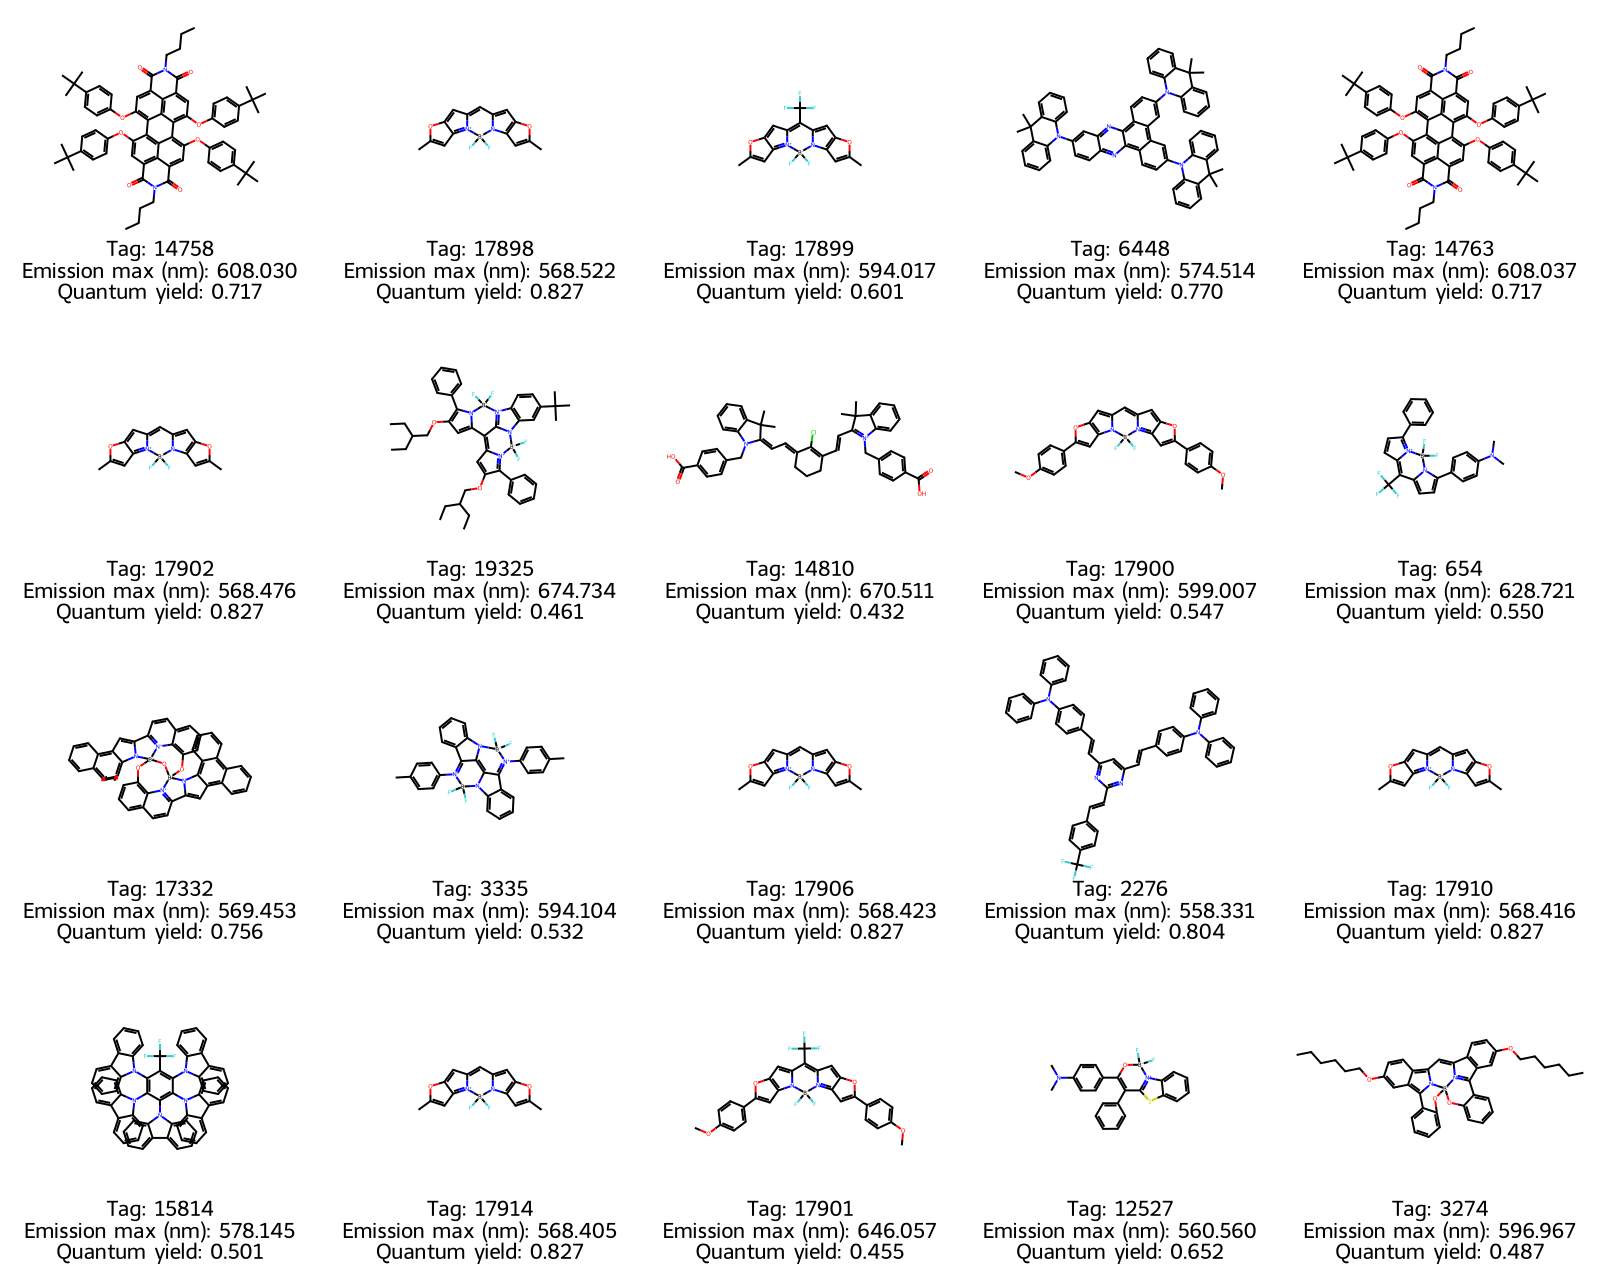

In [12]:
# 選抜候補の化学構造（ループ終了時に Chromophore 付きの bo_selected_summary を利用）

mols = [Chem.MolFromSmiles(s) for s in bo_selected_summary["Chromophore"]]

# 凡例は「選抜ラウンド当時」の予測値（bo_selected_summary）を使う
pred_cols = y.columns.tolist()
legends = []
for tag, row in bo_selected_summary.iterrows():
    values = [f"{col}: {row[col]:.3f}" for col in pred_cols]
    legends.append(f"Tag: {tag}\n" + "\n".join(values))

# Legendの設定
options = Draw.MolDrawOptions()
options.legendFontSize = 32
options.legendFraction = 0.22

display(
    Draw.MolsToGridImage(
        mols,
        molsPerRow=5,
        subImgSize=(320, 320),
        legends=legends,
        drawOptions=options
    )
)

In [13]:
# 保存済みサマリーの確認（Chromophore 付き CSV はループ終了セルで出力済み）
print(f"{save_dir}/bo_selected_summary_multi_y_{regression_method}_{acquisition_mode}.csv")
display(bo_selected_summary)

outputs/result/bo_multi_y_acq_ei_ucb/bo_selected_summary_multi_y_gpr_one_kernel_constrained_ei.csv


,Emission max (nm),Quantum yield,std_of_emission,std_of_plqy,PTR_emission,EI_plqy,acquisition_score,acquisition_mode,Chromophore
tag,,,,,,,,,
14758,608.029649,0.716693,38.953175,0.215463,0.581658,0.009217,0.005361,constrained_ei,CCCCN1C(=O)c2cc(Oc3ccc(C(C)(C)C)cc3)c3c4c(Oc5c...
17898,568.522244,0.826636,38.644471,0.213960,0.207666,0.024620,0.005113,constrained_ei,Cc1cc2c(o1)=CC1=Cc3cc4oc(C)cc4n3[B-](F)(F)[N+]=21
17899,594.016784,0.601338,59.417994,0.285581,0.459895,0.010317,0.004745,constrained_ei,Cc1cc2c(o1)=CC1=C(C(F)(F)F)c3cc4oc(C)cc4n3[B-]...
6448,574.513604,0.769503,38.587655,0.213817,0.254473,0.014893,0.003790,constrained_ei,CC1(C)c2ccccc2N(c2ccc3nc4c5ccc(N6c7ccccc7C(C)(...
14763,608.037474,0.716929,34.939367,0.196713,0.590970,0.006388,0.003775,constrained_ei,CCCCN1C(=O)c2cc(Oc3ccc(C(C)(C)C)cc3)c3c4c(Oc5c...
17902,568.476293,0.826999,34.766799,0.195826,0.182278,0.019697,0.003590,constrained_ei,Cc1cc2c(o1)=CC1=Cc3cc4oc(C)cc4n3[B-](F)(F)[N+]=21
19325,674.734332,0.461426,65.682842,0.298569,0.872097,0.004113,0.003587,constrained_ei,CCC(CC)COC1=CC2=C3c4cc(OCC(CC)CC)c(-c5ccccc5)n...
14810,670.511041,0.432347,75.277879,0.311256,0.824388,0.004081,0.003364,constrained_ei,CC1(C)C(/C=C/C2=C(Cl)/C(=C/C=C3/N(Cc4ccc(C(=O)...
17900,599.007111,0.547190,58.628428,0.283514,0.493244,0.006466,0.003189,constrained_ei,COc1ccc(-c2cc3c(o2)=CC2=Cc4cc5oc(-c6ccc(OC)cc6...
